In [5]:

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# generic multi class nlp
# TODO (s4hlo) collect portuguese data 
# mock data
# 0 - negative
# 1 - neutral
# 2 - positive
data = [
    {"selftext": "Adorei esse produto, me surpreendeu!", "target": 2},
    {"selftext": "Não odeio horrivel gostei da qualidade, deixou a desejar.", "target": 0},
    {"selftext": "É ok, nada demais também.", "target": 1},
    {"selftext": "O atendimento foi excelente, recomendo.", "target": 2},
    {"selftext": "Demorou pessimo muito pra chegar, fiquei frustrado.", "target": 0},
    {"selftext": "Cumpre o que promete, tudo certo.", "target": 2},
    {"selftext": "Mais ou menos, esperava mais.", "target": 1},
    {"selftext": "Veio  odio pessimo  quebrado, não funcionou.", "target": 0},
    {"selftext": "Maravilhoso! Com certeza compraria de novo.", "target": 2},
    {"selftext": "É aceitável pelo preço, mas não é top.", "target": 1},
]

df = pd.DataFrame(data)

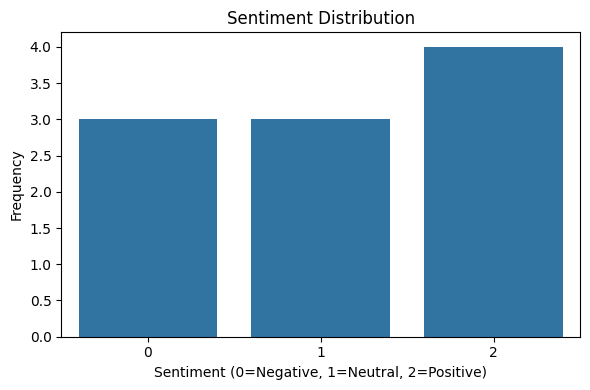

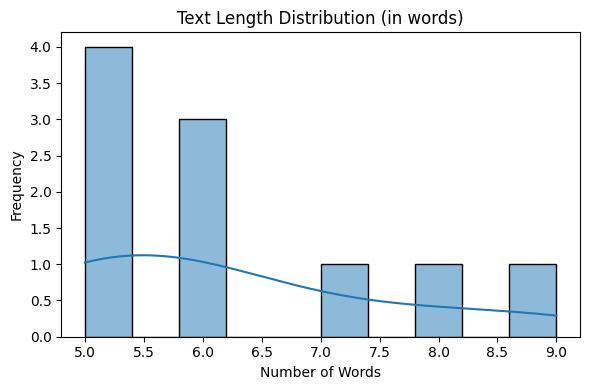

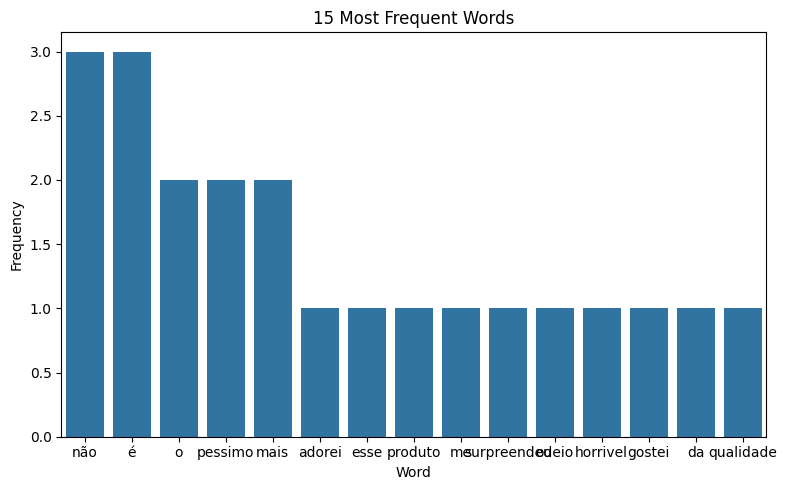

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# TODO (s4hlo) check more relevant metrics

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0=Negative, 1=Neutral, 2=Positive)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

df["text_length"] = df["selftext"].apply(lambda x: len(x.split()))

plt.figure(figsize=(6, 4))
sns.histplot(df["text_length"], bins=10, kde=True)
plt.title("Text Length Distribution (in words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

all_words = [word for text in df["selftext"] for word in tokenize(text)]
word_freq = Counter(all_words).most_common(15)
words, freqs = zip(*word_freq)

plt.figure(figsize=(8, 5))
sns.barplot(y=list(freqs), x=list(words),)
plt.title("15 Most Frequent Words")
plt.ylabel("Frequency")
plt.xlabel("Word")
plt.tight_layout()
plt.show()

/home/sleight/.cache/pypoetry/virtualenvs/pln-qWjcxHse-py3.10/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sleight/.cache/pypoetry/virtualenvs/pln-qWjcxHse-py3.10/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/sleight/.cache/pypoetry/virtualenvs/pln-qWjcxHse-py3.10/lib/python3.10/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


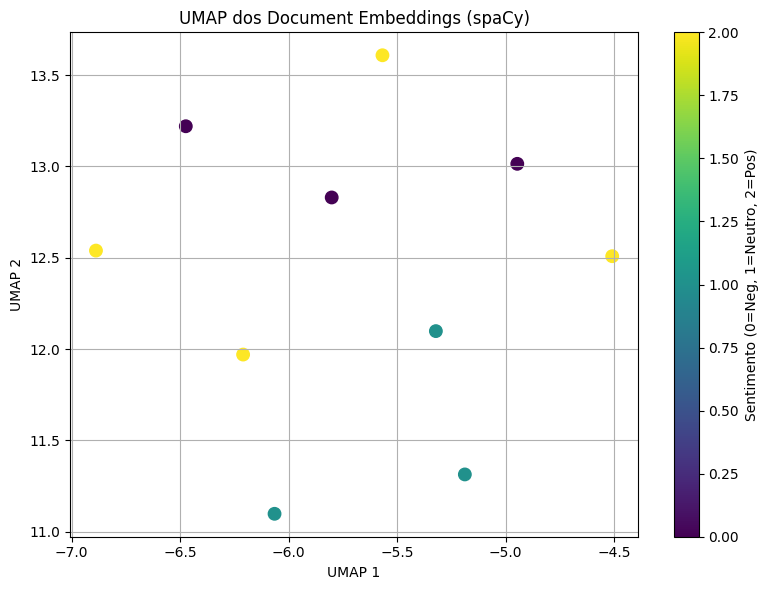

In [ ]:
import spacy
import numpy as np
import umap


nlp = spacy.load("pt_core_news_md")

nlp = spacy.load("pt_core_news_md")

df["embedding"] = df["selftext"].apply(lambda x: nlp(x).vector)

X = np.vstack(df["embedding"].values)
y = df["target"].values

X_umap = umap.UMAP(random_state=42).fit_transform(X)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap="viridis", s=80)
plt.title("UMAP Document Embeddings (spaCy)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Sentimento (0=Neg, 1=Neutro, 2=Pos)")
plt.grid(True)
plt.tight_layout()
plt.show()

pos coleta de dados - tratamento

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
import re

def make_lowercase(text: str) -> str:
    return text.lower()

def remove_excessive_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

pipeline_clean_text = Pipeline(
    steps=[
        ("make_lowercase", FunctionTransformer(lambda x: [make_lowercase(i) for i in x], validate=False)),
        ("remove_excessive_whitespace", FunctionTransformer(lambda x: [remove_excessive_whitespace(i) for i in x], validate=False)),
    ]
)

def safe_clean_text(x):
    try:
        return pipeline_clean_text.transform([str(x)])[0]
    except Exception:
        return x

df["selftext"] = df["selftext"].apply(safe_clean_text)

print("First 5 cleaned texts:")
for i in range(min(5, len(df))):
    print(f"\nText {i + 1}:")
    print(f"Content: {df['selftext'].iloc[i]}")



First 5 cleaned texts:

Text 1:
Content: adorei esse produto, me surpreendeu!

Text 2:
Content: não gostei da qualidade, deixou a desejar.

Text 3:
Content: é ok, nada demais também.

Text 4:
Content: o atendimento foi excelente, recomendo.

Text 5:
Content: demorou muito pra chegar, fiquei frustrado.


In [ ]:
# ------ split 1

# Display the first few rows of the DataFrame
# Drop the 'url' and 'id' columns from the DataFrame
df = df.drop(['url', 'id'], axis=1)

# Convert all text columns to lowercase
df['title'] = df['title'].str.lower()
df['selftext'] = df['selftext'].str.lower()

# Print the first 5 texts from the DataFrame
print("First 5 texts:")
for i in range(5):
    print(f"\nText {i+1}:")
    print(f"Title: {df['title'].iloc[i]}")
    print(f"Selftext: {df['selftext'].iloc[i]}")



# Get the most common words in selftext
from collections import Counter
import re

# Combine all selftext into one string and split into words
all_text = ' '.join(df['selftext'].dropna().astype(str))
words = re.findall(r'\w+', all_text.lower())

# Count word frequencies
word_counts = Counter(words)

# Get the 20 most common words
most_common = word_counts.most_common(20)

# Print the results
print("Most common words in selftext:")
for word, count in most_common:
    print(f"{word}: {count}")






df

First 5 texts:

Text 1:
Title: android app to strengthen attention/focus
Selftext: hey /r/adhd,

check out my simple android app: [attention exercise](https://market.android.com/details?id=com.racecarlabs.apps.android.attentionexercise)

it's just a series of simple touchscreen drawing exercises that, with practice, noticeably improve attention span and focus.  a session really shouldn't take more than a couple of minutes!

if you've heard of the book [delivered from distraction](http://www.amazon.com/delivered-distraction-getting-attention-disorder/dp/034544230x), the app is based on the exercises that dr. hallowell recommends in the book. 

writing code while managing my adhd symptoms hasn't been easy, but i hope this is an encouragement to you!  it felt really good to ship version 1.

if you have feature ideas or bug reports, i'd love to hear them!



on my roadmap:

* optional daily notifications (exercises work best with daily practice)
* tracking improvements
* making it prettier

,title,selftext,score,num_comments,created_utc,created_datetime
0,android app to strengthen attention/focus,"hey /r/adhd,\n\ncheck out my simple android ap...",6,7.0,1315014480.0,2011-09-03 01:48:00
1,does anyone here have experience with imipramine?,my doctor has suggested it for add with anxiet...,4,1.0,1315051084.0,2011-09-03 11:58:04
2,"new study shows that for people with adhd, \n""...",NaN,22,11.0,1315174374.0,2011-09-04 22:12:54
3,what does the adhd test look like?,i'm 21 and didn't know about adhd until recent...,6,10.0,1315239683.0,2011-09-05 16:21:23
4,are you guys good with maps and directions?,it seems like one thing i've always been reall...,0,0.0,1315317191.0,2011-09-06 13:53:11
...,...,...,...,...,...,...
336061,meds not working / lack of sleep to blame?,hi everyone\n\ni started taking mph 2 weeks ag...,1,2.0,1613046880.0,2021-02-11 12:34:40
336062,how to deal with friends who tell you to be ca...,[deleted],2,7.0,1613047275.0,2021-02-11 12:41:15
336063,"atomoxetine side effects were too harsh, appre...",hello everyone!\n\ni’ve been a part of this su...,1,2.0,1613047850.0,2021-02-11 12:50:50
336064,lto3 experiences,[removed],2,0.0,1613047852.0,2021-02-11 12:50:52
